# RNE Control / Corrector

This notebook is a tutorial of RNE for diffusion / Stochastic interpolant control.
We will first learn a diffusion model for Gaussian Mixture Model, and then demonstrate how to control it using SMC, with weight calculated by RNE. 


This notebook will explain the calculation with RNE for annealing.
Produce and tilting will follow the same logic. 



## Prepare

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import OrderedDict
from mlp import MLP

In [2]:
dim = 2
n_mix = 40
loc_scale = 1.0
log_var = -3.5

In [3]:
device = 'cpu'

### Define GMM Target

In [4]:

import torch
import numpy as np
from matplotlib import pyplot as plt
import itertools


class GMM(torch.nn.Module):
    def __init__(self, dim, n_mixes, loc_scaling, log_var_scaling=0.1, mean_shift=0,  seed=0,
                 n_test_set_samples=1000, device="cpu"):
        super(GMM, self).__init__()
        torch.manual_seed(seed)

        self.seed = seed
        self.n_mixes = n_mixes
        self.dim = dim
        self.n_test_set_samples = n_test_set_samples

        mean = (torch.rand((n_mixes, dim)) - 0.5)*2 * loc_scaling + mean_shift
        log_var = torch.ones((n_mixes, dim)) * log_var_scaling

        self.register_buffer("cat_probs", torch.ones(n_mixes))
        self.register_buffer("locs", mean)
        self.register_buffer("scale_trils", torch.diag_embed(torch.nn.functional.softplus(log_var)))
        self.device = device
        self.to(self.device)

        self.call_time = 0

    def to(self, device):
        if device == "cuda":
            if torch.cuda.is_available():
                self.cuda()
        else:
            self.cpu()

    @property
    def distribution(self):
        mix = torch.distributions.Categorical(self.cat_probs.to(self.device))
        com = torch.distributions.MultivariateNormal(self.locs.to(self.device),
                                                     scale_tril=self.scale_trils.to(self.device),
                                                     validate_args=False)
        return torch.distributions.MixtureSameFamily(mixture_distribution=mix,
                                                     component_distribution=com,
                                                     validate_args=False)

    @property
    def test_set(self) -> torch.Tensor:
        return self.sample((self.n_test_set_samples, ))

    def log_prob(self, x: torch.Tensor, count_call=True):
        log_prob = self.distribution.log_prob(x)
        mask = torch.zeros_like(log_prob)
        mask[log_prob < -1e4] = - torch.tensor(float("inf"))
        log_prob = log_prob + mask
        if count_call:
            self.call_time += x.shape[0]
        return log_prob

    def score(self, x: torch.Tensor, count_call=True):
        with torch.enable_grad():
            x.requires_grad = True
            logp = self.log_prob(x, count_call)
            score = torch.autograd.grad(logp.sum(), x)[0]
        return score 

    def sample(self, shape=(1,), count_call=True):
        if count_call:
            self.call_time += shape[0]
        return self.distribution.sample(shape)
    
    def get_sample_and_logp(self, shape=(1,), count_call=True):
        samples = self.sample(shape, count_call)
        logp = self.log_prob(samples, count_call)
        return samples, logp
    
    def get_sample_and_score(self, shape=(1,), count_call=True):
        samples = self.sample(shape, count_call)
        with torch.enable_grad():
            samples.requires_grad = True
            logp = self.log_prob(samples, count_call)
            score = torch.autograd.grad(logp.sum(), samples)[0]
        return samples.detach(), score

In [5]:
import itertools

def plot_contours(log_prob_func,
                  bounds = (-2.0, 2.0),
                  grid_width_n_points = 20,
                  n_contour_levels = None,
                  log_prob_min = -1000.0,
                  device='cpu',):
    x_points_dim1 = torch.linspace(bounds[0], bounds[1], grid_width_n_points)
    x_points_dim2 = x_points_dim1
    x_points = torch.tensor(list(itertools.product(x_points_dim1, x_points_dim2)), device=device)
    log_p_x = log_prob_func(x_points.to(device)).cpu().detach()
    log_p_x = torch.clamp_min(log_p_x, log_prob_min)
    log_p_x = log_p_x.reshape((grid_width_n_points, grid_width_n_points))
    x_points_dim1 = x_points[:, 0].reshape((grid_width_n_points, grid_width_n_points)).cpu().numpy()
    x_points_dim2 = x_points[:, 1].reshape((grid_width_n_points, grid_width_n_points)).cpu().numpy()
    if n_contour_levels:
        plt.contour(x_points_dim1, x_points_dim2, log_p_x, levels=n_contour_levels, linewidths=1.0)
    else:
        plt.contour(x_points_dim1, x_points_dim2, log_p_x, linewidths=0.5)

In [6]:
gmm = GMM(dim, n_mix, loc_scale, log_var)

### Train Network

**You can train your own model using the following code.**


In [7]:
# def DSM_loss(x_t, models, x0, t):
#     w = (models.data_sigma*t)**2  / (models.data_sigma**2 + t**2)
#     x_hat = models(x_t, t)
#     dsm_loss = (((x0 - x_hat)**2).sum(-1)/w).mean()
#     return dsm_loss


# def update_sg_model(mu, online_model, sg_model):
#     with torch.no_grad():
#         online_params = OrderedDict(online_model.named_parameters())
#         sg_params = OrderedDict(sg_model.named_parameters())

#         # check if both model contains the same set of keys
#         assert online_params.keys() == sg_params.keys()

#         for name, param in online_params.items():
#             # see https://www.tensorflow.org/api_docs/python/tf/train/ExponentialMovingAverage
#             # shadow_variable -= (1 - decay) * (shadow_variable - variable)
#             sg_params[name].sub_((1. - mu) * (sg_params[name] - param))
#             sg_params[name].require_grad = False

#         online_buffers = OrderedDict(online_model.named_buffers())
#         sg_buffers = OrderedDict(sg_model.named_buffers())

#         # check if both model contains the same set of keys
#         assert online_buffers.keys() == sg_buffers.keys()

#         for name, buffer in online_buffers.items():
#             # buffers are copied
#             sg_buffers[name].copy_(buffer)

# from copy import deepcopy

# denoising_net = MLP(dim, device, 0.58).to(device)
# opt = torch.optim.Adam(denoising_net.parameters(), lr=1e-3)

# ema_decay = 0.999
# ema_net = deepcopy(denoising_net).to(device)

# n_epoch = 100000
# batch_size = 1024

# LOSS = []
# for epoch in tqdm(range(n_epoch)):
#     data = gmm.sample([batch_size]).to(device)
#     x = data

#     logt = torch.randn(batch_size).to(device) * 1.2 - 1.2
#     noises = torch.randn_like(x)
#     x_t = x + noises * logt.exp()[:, None]

#     loss = DSM_loss(x_t, denoising_net, x, logt.exp())
#     loss.backward()
#     opt.step()
#     opt.zero_grad()
#     LOSS.append(loss.item())

#     update_sg_model(ema_decay, denoising_net, ema_net)
    


# # save the ema model
# torch.save(ema_net.state_dict(), 'ema_net.pt')


In [8]:
# You can also load a pretrained model

ema_net = MLP(dim, device, 0.58).to(device)
ema_net.load_state_dict(torch.load('ema_net.pt'))

<All keys matched successfully>

(-1.2, 1.2)

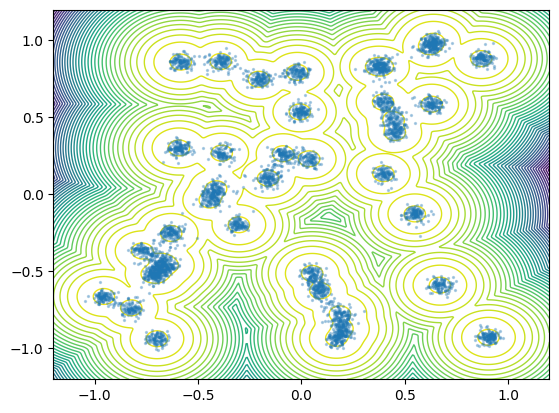

In [9]:
def EM_solve(model, start_samples, ts):
    with torch.no_grad():
        samples = start_samples
        for i in range(ts.shape[0]-1, 0, -1):
            t = torch.ones(samples.shape[0], 1).to(samples.device) * ts[i]
            t_1 = torch.ones(samples.shape[0], 1).to(samples.device) * ts[i-1]

            Delta_t = (t - t_1).abs()
            x_hat = model(samples, t.squeeze(-1)) 
            std = torch.sqrt(2*Delta_t*t)
            score = - (samples - x_hat) / t ** 2

            dx = score * 2 * t * Delta_t + std * torch.randn_like(samples) 

            samples = samples + dx
        return samples


tmax = 10
tmin = 1e-3
rho = 7
steps = 100
ts = tmin ** (1/rho) + np.arange(steps)/(steps-1) * (tmax ** (1/rho) - tmin ** (1/rho))
ts = ts ** rho


samples = EM_solve(ema_net, torch.randn(5000, dim, device=device)*ts[-1], ts)
plot_contours(gmm.log_prob, bounds=(-1.2, 1.2), grid_width_n_points=400, n_contour_levels=40, log_prob_min=-1000.0)
data = gmm.sample([5000]).to(device)
plt.scatter(samples.cpu().detach()[:, 0], samples.cpu().detach()[:, 1], alpha=0.3, s=2, zorder=2)
plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)


## RN Corrector (RNC)

#### Sequential Monte Carlo

We first introduce SMC for diffusion model control.
Imagine we have a diffusion  model with marginal density $p_n$ at time step $t_n$.
We now want to obtain samples from some skewed distribution $q_n$.
How can we do that using SMC?

To do so, 


(1) we can first start from particles at $q_N$. This is easy, as $p_N$ are simply Gaussian for diffusion model, and we can easily obtain the form of $q_N$ and draw sample from it.

(2) having particles at step $n+1$, we consider how to obtain particles at step $n$. If we can do this, we can evolve particles at $N$ all the way down to $n=0$, corresponding to previous clean data, but annealed.

So the question is: ***having particles at step $n+1$, how to obtain particles at step $n$***?

To do so, we define a proposal kernel $q(x_n|x_{n+1})$. This can be anything sensible.
We also define an auxiliary kernel $q(x_{n+1}|x_n)$. This can also be chosen as any sensible kernel.

Then, we sample $x_n\sim q(x_n|x_{n+1})$ for each $x_{n+1}$ particle, and calculate the SMC weight:

\begin{align}
w = \frac{q(x_n)  q(x_{n+1}|x_n)}{q(x_{n+1}) q(x_n|x_{n+1})}
\tag{*}
\end{align}

As the transition kernels are defined by ourselves, we know its analytical form. The only unknown term is $\frac{q(x_n)  }{q(x_{n+1}) }$.

So the question can be simplified as:  ***how to calculate $\frac{q(x_n)  }{q(x_{n+1}) }$ for a diffusion model***?
Here comes our RNEC.




#### Intuitive Explanation on RNEC

RNE is based on the following observation:

> For a well trained diffusion model, the forward process (noising process) and the backward process (denoising process) defines the same probabilty distribution.

The forward process from $t_n$ to $t_m$ is: $$p_n(x_n)p(x_{n+1}|x_n) \cdots p(x_{m}|x_{m-1})$$
The transiton kernels $p(x_{n+1}|x_n) \cdots p(x_{m}|x_{m-1})$ are simply Gaussian noising kernels.

The backward process from $t_m$ is: $$p_m(x_m)p(x_{m-1}|x_m) \cdots p(x_{n}|x_{n+1})$$
The transiton kernels $p_m(x_m)p(x_{m-1}|x_m) \cdots p(x_{n}|x_{n+1})$ are also simply Gaussian denoising kernels (with the learned score network).

Therefore, 
\begin{align*}
p_n(x_n)
p(x_{n+1}|x_n) \cdots p(x_{m}|x_{m-1})  =  p_m(x_m)p(x_{m-1}|x_m) \cdots p(x_{n}|x_{n+1})
\end{align*}


This is an intuitive explanation to the RNE in discrete time. In continuous-time limit, we also provide its form in the paper. 

For simplicity, we will only consider 1 step in the following. That is:
\begin{align}
p_n(x_n) / p_{n+1}(x_{n+1})
 =  p(x_{n}|x_{n+1}) / p(x_{n+1}|x_n) 
\tag{**}
\end{align}


Then the final step is to look at the relation between $q$ and $p$.
For example, for annealing, we have $q_n = p_n^\beta$; for reward tilting, we have $q_n = p_n \exp(r_n)$; for product, we have $q_n=p_n p_n '$.
Therefore, taking annealing for example, we can easily write

\begin{align}
q_n(x_n) / q_{n+1}(x_{n+1}) = (p_n(x_n) / p_{n+1}(x_{n+1}))^\beta
\tag{***}
\end{align}


**Note that this also works for stochastic interpolants. The only requirement is that the model has forward and backward process that are time-reversal.**


#### RNEC with Analytical Reference

In our paper, we introduce an analytical reference to reduce the error of RNE.

An intuitive motivation for the reference is as follows. The discretisation error for forward process and backward process is different. Even the estimator is valid in continuous time, it does not mean there is numerical-error free in discrete time. To reduce the error, a better way is to introduce a pair of forward-forward process (or backward-backward), instead of a forward-backward pair.

Luckily, for the diffusion model we typically choose, if we start from a Gaussian distribution, then we know everything for the process: the marginal, the score, the transition kernel, etc. Therefore, we can directly write down its forward and backward process:

\begin{align}
 &\pi_n(x_n)\pi(x_{n+1}|x_n) \\ &= \\ &\pi_{n+1}(x_{n+1})\pi(x_{n}|x_{n+1}) 
\end{align}


For example, in our example in this notebook, we start from a Gaussian $\pi_0=\mathcal{N}(0, I)$, and the noising process follows EDM. Therefore, $\pi_t=\mathcal{N}(0, (1+t^2)I)$. Using this we can calculate the forward and backward transition kernel. In the code, this is done by 

```python
# analytical marginal std and score
ref_std = lambda time: (1**2 + time ** 2)**0.5
ref_score = lambda x, time: - x / ref_std(time) ** 2

# ref forward process
fwd_mean = samples_new
fwd_std = torch.sqrt(2*Delta_t*t_1)
ref_fwd = log_norm_prob(samples_new, 0, ref_std(t_1)) # marginal density at t_1
ref_fwd += log_norm_prob(samples, fwd_mean, fwd_std) # transition kernel density from t to t_1

# ref backward process
bwd_mean = samples + ref_score(samples, t) * 2 * t * Delta_t
bwd_std = torch.sqrt(2*Delta_t*t)
ref_bwd = log_norm_prob(samples, 0, ref_std(t)) # marginal density at t
ref_bwd += log_norm_prob(samples_new, bwd_mean, bwd_std) # transition kernel density from t_1 to t

```


From equation (1)-(3), we know in the ideal case, (1) should be the same  as (3). Therefore, we can freely insert (1)/(3) to our previous estimator (**).


This gives us a more stable and more accurate estimator:


\begin{align}
\frac{p_n(x_n)}{ p_{n+1}(x_{n+1}) }= \frac{p(x_{n}|x_{n+1}) }{ p(x_{n+1}|x_n) } \frac{  \pi_n(x_n)\pi(x_{n+1}|x_n) }{ \pi_{n+1}(x_{n+1})\pi(x_{n}|x_{n+1}) }\tag{****}
\end{align}

This does not only apply to RNE estimator, but also apply to the SMC weight (\*). In other word, the SMC weight is given by:
\begin{align}
w = \frac{q(x_n) }{q(x_{n+1}) } \frac{q(x_{n+1}|x_n)}{q(x_n|x_{n+1})}  \frac{ \pi_{n+1}(x_{n+1})\pi(x_{n}|x_{n+1}) }{  \pi_n(x_n)\pi(x_{n+1}|x_n) }
\tag{*****}
\end{align}
with $ \frac{q(x_n) }{q(x_{n+1}) } $ estimated as (****).






#### Experiments

Now, let's look at the codes and experiments

In [10]:
def log_norm_prob(x, mu, std):
    """
    Gaussian log density
    """
    # expand std to match x shape
    std = std.expand(x.shape)
    return -0.5 * ((x - mu) / std).pow(2).sum(-1) - (std.log() + np.log(2*np.pi)/2).sum(-1)


In [11]:
def EM_solve_temper_rnc(model, start_samples, beta, fwd_lamb, bwd_lamb, ts, with_reference=False):
    with torch.no_grad():
        samples = start_samples
        bsz = samples.shape[0]
        w = 0
        acc_w = 0
        ESS = []
        Samples = []

        Resample = 0
        for i in tqdm(range(ts.shape[0]-1, 0, -1)):
            t = torch.ones(samples.shape[0], 1).to(samples.device) * ts[i]
            t_1 = torch.ones(samples.shape[0], 1).to(samples.device) * ts[i-1]

            Delta_t = (t - t_1).abs()
            x_hat = model(samples, t.squeeze(-1)) 
            score = - (samples - x_hat) / t ** 2

            std = torch.sqrt(2*Delta_t*t)

            dx = score * 2 * t * Delta_t * beta *  bwd_lamb + std *  torch.randn_like(samples)

            samples_new = samples + dx

            # diffusion forward process
            fwd_mean = samples_new
            fwd_std = torch.sqrt(2*Delta_t*t_1)
            dm_fwd = log_norm_prob(samples, fwd_mean, fwd_std) 

            # diffusion backward process
            bwd_mean = samples + score * 2 * t * Delta_t
            bwd_std = torch.sqrt(2*Delta_t*t)
            dm_bwd = log_norm_prob(samples_new, bwd_mean, bwd_std)


            # sampling forward process, you can also modify the forward process to other processes. Here we use fwd_lamb to control the forward process.
            x_hat_new = model(samples_new, t_1.squeeze(-1)) 
            score_new = - (samples_new - x_hat_new) / t_1 ** 2

            fwd_mean = samples_new + score_new * 2 * t_1 * Delta_t * beta * fwd_lamb
            fwd_std = torch.sqrt(2*Delta_t*t_1)
            sample_fwd = log_norm_prob(samples, fwd_mean, fwd_std) 

            # sampling backward process, you can also modify the backward process to other processes. Here we use bwd_lamb to control the backward process.
            bwd_mean = samples + score * 2 * t * Delta_t * beta * bwd_lamb
            bwd_std = torch.sqrt(2*Delta_t*t)
            sample_bwd = log_norm_prob(samples_new, bwd_mean, bwd_std)

            if not with_reference:

                # log weight
                w = w + (sample_fwd - sample_bwd) + (dm_bwd - dm_fwd) * beta

                acc_w = acc_w+ (sample_fwd - sample_bwd) + (dm_bwd - dm_fwd) * beta
            
            else:
                # first define reference distribution
                ref_std = lambda time: (1**2 + time ** 2)**0.5
                ref_score = lambda x, time: - x / ref_std(time) ** 2
                # ref forward process
                fwd_mean = samples_new
                fwd_std = torch.sqrt(2*Delta_t*t_1)
                ref_fwd = log_norm_prob(samples_new, 0, ref_std(t_1)) + log_norm_prob(samples, fwd_mean, fwd_std) 

                # ref backward process
                bwd_mean = samples + ref_score(samples_new, t) * 2 * t * Delta_t
                bwd_std = torch.sqrt(2*Delta_t*t)
                ref_bwd = log_norm_prob(samples, 0, ref_std(t)) + log_norm_prob(samples_new, bwd_mean, bwd_std)

                # log weight
                w = w + (sample_fwd - ref_fwd - sample_bwd + ref_bwd) + (dm_bwd - ref_bwd - dm_fwd + ref_fwd) * beta

                acc_w = acc_w + (sample_fwd - ref_fwd - sample_bwd + ref_bwd) + (dm_bwd - ref_bwd - dm_fwd + ref_fwd) * beta

            # calculate ESS
            _w = torch.nn.Softmax(0)(w)
            ess = _w.sum() ** 2 / (_w ** 2).sum()  
            ESS.append(ess.item())

            # resample
            # clip w
            if ess < 0.75 * bsz or i == 1:
                _w = torch.clamp(_w, max=_w.quantile(0.999999))
                _w = _w.detach().cpu().numpy() + 1e-10
                resample_idx = np.random.choice(bsz, (bsz, ), p=_w/_w.sum())
                samples = samples_new[resample_idx]
                w = 0
                Resample += 1
            else:
                samples = samples_new

            Samples.append(samples.detach().cpu().numpy())

        return samples, ESS, Samples, Resample, acc_w.var()   

        

In [18]:

tmax = 10
tmin = 1e-3
rho = 7
steps = 100
ts = tmin ** (1/rho) + np.arange(steps)/(steps-1) * (tmax ** (1/rho) - tmin ** (1/rho))
ts = ts ** rho

beta = 2.5
samples, ESS, Samples, Resample, w_var = EM_solve_temper_rnc(ema_net, torch.randn(5000, dim, device=device)*ts[-1]/np.sqrt(beta), beta=beta, 
                                                            fwd_lamb=0.0, bwd_lamb=1.0, ts=ts, with_reference=True)

100%|██████████| 99/99 [00:03<00:00, 28.68it/s]


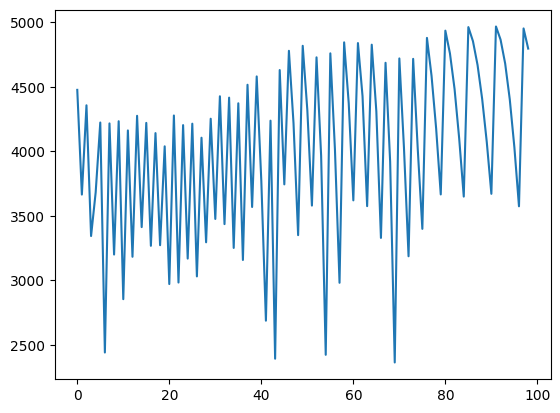

In [19]:
plt.plot(ESS)

(-1.2, 1.2)

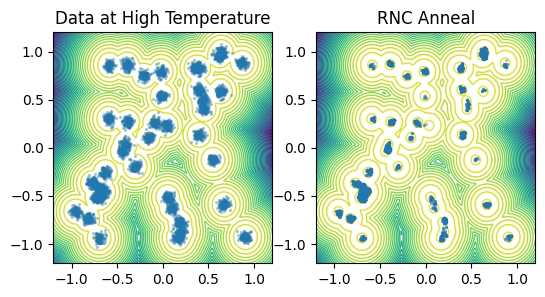

In [20]:
plt.figure(figsize=(13, 3))
plt.subplot(1, 4, 1)



plot_contours(gmm.log_prob, bounds=(-1.2, 1.2), grid_width_n_points=400, n_contour_levels=40, log_prob_min=-1000.0)
data = gmm.sample([5000]).to(device)
plt.scatter(data.cpu().detach()[:, 0], data.cpu().detach()[:, 1], alpha=0.3, s=2, zorder=2)
plt.title('Data at High Temperature')
plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
plt.subplot(1, 4, 2)
plot_contours(gmm.log_prob, bounds=(-1.2, 1.2), grid_width_n_points=400, n_contour_levels=40, log_prob_min=-1000.0)
orig_samples = gmm.sample([10000]).to(device)
plt.scatter(samples.cpu().detach()[:, 0], samples.cpu().detach()[:, 1], alpha=0.3, s=2, zorder=2)
plt.title('RNC Anneal')
plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)

In [24]:
### You can also use RNEC without reference
### This is okay-ish for 2D, but can be problematic for high-dimensional cases
tmax = 10
tmin = 1e-3
rho = 7
steps = 100
ts = tmin ** (1/rho) + np.arange(steps)/(steps-1) * (tmax ** (1/rho) - tmin ** (1/rho))
ts = ts ** rho

beta = 2.5
samples, ESS, Samples, Resample, w_var = EM_solve_temper_rnc(ema_net, torch.randn(5000, dim, device=device)*ts[-1]/np.sqrt(beta), beta=beta, 
                                                            fwd_lamb=0.0, bwd_lamb=1.0, ts=ts, with_reference=False)

100%|██████████| 99/99 [00:03<00:00, 29.10it/s]


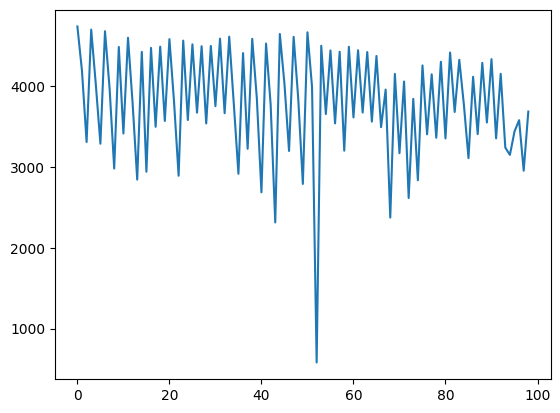

In [25]:
plt.plot(ESS)

(-1.2, 1.2)

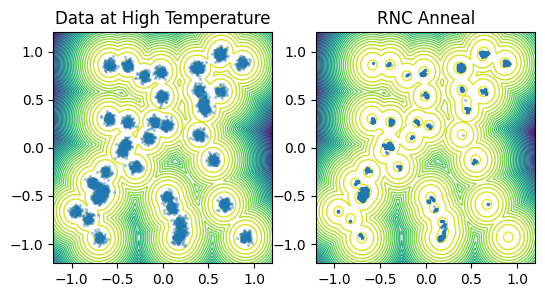

In [26]:
plt.figure(figsize=(13, 3))
plt.subplot(1, 4, 1)



plot_contours(gmm.log_prob, bounds=(-1.2, 1.2), grid_width_n_points=400, n_contour_levels=40, log_prob_min=-1000.0)
data = gmm.sample([5000]).to(device)
plt.scatter(data.cpu().detach()[:, 0], data.cpu().detach()[:, 1], alpha=0.3, s=2, zorder=2)
plt.title('Data at High Temperature')
plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
plt.subplot(1, 4, 2)
plot_contours(gmm.log_prob, bounds=(-1.2, 1.2), grid_width_n_points=400, n_contour_levels=40, log_prob_min=-1000.0)
orig_samples = gmm.sample([10000]).to(device)
plt.scatter(samples.cpu().detach()[:, 0], samples.cpu().detach()[:, 1], alpha=0.3, s=2, zorder=2)
plt.title('RNC Anneal')
plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)